# Lineare Regression: Einkommen vorhersagen (`ConvertedCompTotal`)

Naives Modell, dass nur mit `WorkExp` und `Country` versucht `ConvertedCompTotal` vorherzusagen


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold


In [2]:

df = pd.read_csv("../../One-Hot-Encoded.csv")


q98 = df["ConvertedCompTotal"].dropna().quantile(0.98)
df = df[df["ConvertedCompTotal"] <= q98].copy()
print(df["ConvertedCompTotal"].describe())

df = df[df["ConvertedCompTotal"] > 10000].copy()

bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)
df.dtypes

# Droppe alles außer WorkExp und alle Country One-Hot-Encoding Spalten
country_cols = [col for col in df.columns if col.startswith("Country_")]
cols_to_keep = country_cols + ["ConvertedCompTotal"]
df = df[cols_to_keep].copy()

count     21785.000000
mean      86982.492836
std       63772.008524
min           0.000000
25%       40873.000000
50%       75924.190383
75%      120000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64


In [3]:
TARGET = "ConvertedCompTotal"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()


# Konsistentes Dropna (X vollständig + y vorhanden)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("After dropna -> X:", X.shape, "y:", y.shape)
y.describe()

After dropna -> X: (19465, 175) y: (19465,)


count     19465.000000
mean      97016.291888
std       60041.912971
min       10000.000000
25%       52939.485715
50%       84081.600000
75%      128458.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64

In [4]:
y_model = y.astype(float)
y_model.head()

0     61659.84
1    105102.00
3     36435.36
4     60000.00
5    120000.00
Name: ConvertedCompTotal, dtype: float64

In [5]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (15572, 175) Test: (3893, 175)


In [6]:
# Grid Search (Ridge / Lasso / ElasticNet) mit Preprocessing-Pipeline

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold

pipe = Pipeline([
    ("model", Ridge())  # Platzhalter
])

param_grid = [
    {
        "model": [Ridge()],
        "model__alpha": [0.01, 0.1, 1, 10, 100, 300, 1000]
    },
    {
        "model": [Lasso(max_iter=20000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
    },
    {
        "model": [ElasticNet(max_iter=20000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    }
]

#cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE minimieren
    cv=3,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

print("Bestes Modell:", grid.best_estimator_.named_steps["model"])
print("Beste Parameter:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

best_pipe = grid.best_estimator_
clf = best_pipe.named_steps["model"]  # für nachfolgende Zellen (Intercept / Coefs etc.)


/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.010e+13, tolerance: 3.793e+09
  model = cd_fast.enet_coordinate_descent(
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.017e+13, tolerance: 3.734e+09
  model = cd_fast.enet_coordinate_descent(
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Bestes Modell: ElasticNet(alpha=0.001, max_iter=20000)
Beste Parameter: {'model': ElasticNet(max_iter=20000), 'model__alpha': 0.001, 'model__l1_ratio': 0.5}
Best CV RMSE: 48619.36170512136


In [7]:
# Prediction + Metriken (Best Model aus Grid Search)

predicted = best_pipe.predict(X_test)
expected = y_test

test_predict_mean = np.full(len(y_test), y_train.mean())
print("Baseline Mean RMSE:")
rmse_baseline = np.sqrt(mean_squared_error(expected, test_predict_mean))
print(rmse_baseline)

print("RMSE:")
rmse = np.sqrt(mean_squared_error(expected, predicted))
print(rmse)

print("R^2:")
r2 = r2_score(expected, predicted)
print(r2)

print("MAE:")
mae = mean_absolute_error(expected, predicted)
print(mae)


Baseline Mean RMSE:
59495.86848477912
RMSE:
48431.80111639526
R^2:
0.33734455579390565
MAE:
35526.244889167014


In [8]:
# (Optional) Top-Ergebnisse aus der Cross-Validation (nach RMSE sortiert)

cv_res = pd.DataFrame(grid.cv_results_)
cols_show = ["rank_test_score", "mean_test_score", "std_test_score", "params"]
cv_res_sorted = cv_res[cols_show].sort_values("rank_test_score").head(10)

# RMSE aus neg_root_mean_squared_error zurückrechnen
cv_res_sorted = cv_res_sorted.assign(
    mean_RMSE = -cv_res_sorted["mean_test_score"],
    std_RMSE = cv_res_sorted["std_test_score"]
).drop(columns=["mean_test_score", "std_test_score"])

cv_res_sorted


,rank_test_score,params,mean_RMSE,std_RMSE
20,1,"{'model': ElasticNet(max_iter=20000), 'model__...",48619.361705,461.350592
19,2,"{'model': ElasticNet(max_iter=20000), 'model__...",48620.956055,463.996301
18,3,"{'model': ElasticNet(max_iter=20000), 'model__...",48626.814295,466.911941
21,4,"{'model': ElasticNet(max_iter=20000), 'model__...",48626.837724,460.347187
12,5,"{'model': Lasso(max_iter=20000), 'model__alpha...",48627.266651,469.328171
3,6,"{'model': Ridge(), 'model__alpha': 10}",48629.230825,467.823830
27,7,"{'model': ElasticNet(max_iter=20000), 'model__...",48630.745256,468.350017
22,8,"{'model': ElasticNet(max_iter=20000), 'model__...",48664.227430,469.002499
2,9,"{'model': Ridge(), 'model__alpha': 1}",48665.707785,469.476494
13,10,"{'model': ElasticNet(max_iter=20000), 'model__...",48668.375254,470.350258


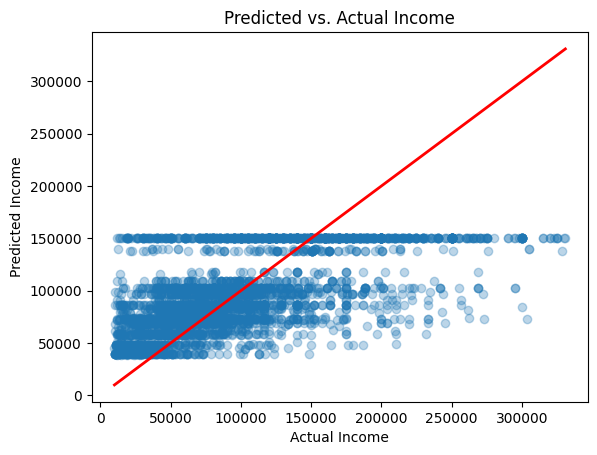

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(expected, predicted, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs. Actual Income")
plt.show()



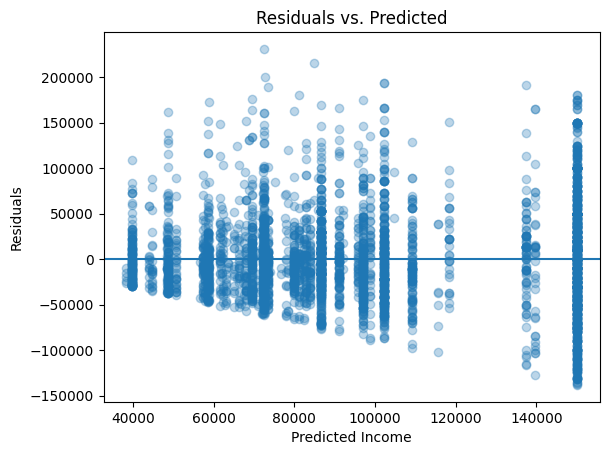

In [10]:
residuals = expected - predicted

plt.figure()
plt.scatter(predicted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()


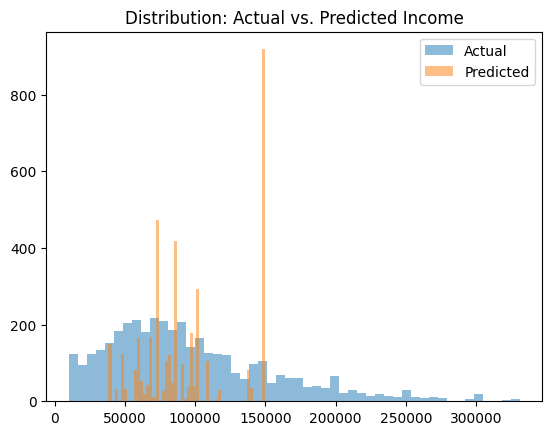

In [11]:
plt.figure()
plt.hist(expected, bins=50, alpha=0.5, label="Actual")
plt.hist(predicted, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs. Predicted Income")
plt.show()


In [12]:
print("Intercept:", clf.intercept_)

# Feature-Namen in der Reihenfolge des ColumnTransformers:
feature_names = num_cols + dummy_cols

coeff_df = pd.DataFrame({"Feature": feature_names, "Coefficient": clf.coef_})
print("\nFeature Coefficients:\n", coeff_df)


Intercept: 72651.00878678149


NameError: name 'dummy_cols' is not defined

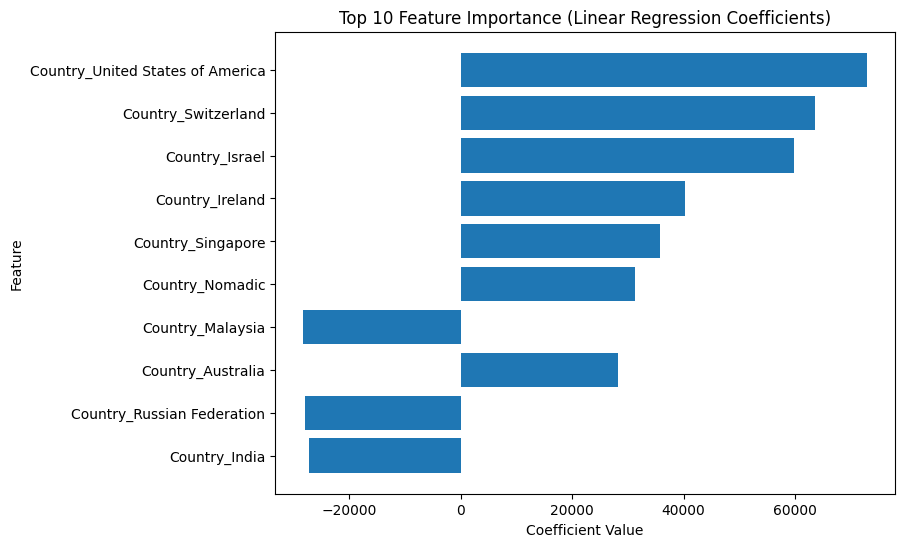

In [ ]:
# Sort by absolute coefficient value and take top 10
coef_df_sorted = (
    coeff_df
    .assign(abs_coef=coeff_df["Coefficient"].abs())
    .sort_values(by="abs_coef", ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(coef_df_sorted["Feature"], coef_df_sorted["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Linear Regression Coefficients)")
plt.gca().invert_yaxis()  # highest importance on top
plt.show()


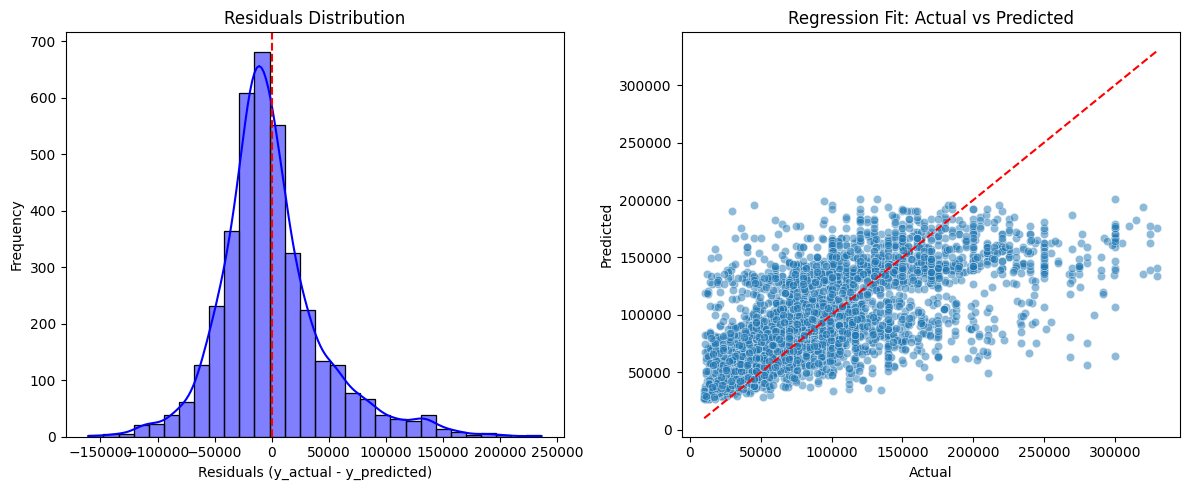

In [ ]:
# Compute residuals.
residuals = expected - predicted

# Create plots.
plt.figure(figsize=(12,5))


# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")


# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
sns.scatterplot(x=expected, y=predicted, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")


# Show plots.
plt.tight_layout()
plt.show()